# DSC 450 Project 1: NOAA Storm Events — Data Visualizations

**Project:** Predicting Extreme Weather Severity Using NOAA Storm Records  
**Author:** Hali Sarah Parsons  
**Role:** Data Visualizer / Presenter  
**Dataset:** NOAA_Storm_Events_Cleaned.csv (cleaned by Andrea Barfield)  
**Purpose:** Produce visualizations that explore storm event frequency, severity, human impact, and economic damage across event types, regions, and seasons (2020–2025).

## 1. Import Libraries

In [4]:
# Title:       DSC 450 Project 1 Visualizations
# Author:      Hali Sarah Parsons
# Date:        2026-09-29
# Modified By:
# Description: Nine visualizations covering storm event frequency, severity,
#              human impact, economic damage, and temporal trends using the
#              NOAA Storm Events cleaned dataset (2020-2025).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- Color palette: navy, teal, purple (Hali's portfolio palette) ---
NAVY   = '#1B2A49'
TEAL   = '#2E8B8B'
PURPLE = '#6A4C93'
LIGHT  = '#E8F4F4'
ACCENT = '#F4A261'

PALETTE = [NAVY, TEAL, PURPLE, ACCENT, '#264653', '#A8DADC', '#457B9D', '#E63946']

# Apply consistent style across all charts
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LIGHT,
    'axes.edgecolor':   NAVY,
    'axes.labelcolor':  NAVY,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  NAVY,
    'xtick.color':      NAVY,
    'ytick.color':      NAVY,
    'font.family':      'sans-serif',
    'grid.color':       'white',
    'grid.linewidth':   0.8,
})

## 2. Load the Cleaned Dataset

In [5]:
# Load the cleaned dataset produced by the Data Wrangler
# Make sure NOAA_Storm_Events_Cleaned.csv is in the same folder as this notebook
df = pd.read_csv('NOAA_Storm_Events_Cleaned.csv', low_memory=False)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Rows: 410,311
Columns: 65


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,TOTAL_FATALITIES,ANY_HUMAN_IMPACT,TOTAL_ECONOMIC_DAMAGE_USD,TOTAL_ECONOMIC_IMPACT_USD,MAJOR_PROPERTY_DAMAGE,REGION,REGION_Midwest,REGION_Northeast,REGION_South,REGION_West
0,202006,24,1620,202006,24,1620,149684,902190,GEORGIA,13,...,0,0,0.0,0.0,0,South,0,0,1,0
1,202006,20,1930,202006,20,1930,149048,898391,KANSAS,20,...,0,0,NaN,NaN,0,Midwest,1,0,0,0
2,202006,3,1550,202006,3,1550,149149,899120,KANSAS,20,...,0,0,NaN,NaN,0,Midwest,1,0,0,0


## 3. Visualizations

Each visualization is built to answer a specific research question about storm event frequency, severity, and impact.

### Chart 1: Top 15 Event Types by Frequency, with Economic-Damage Overlay

This chart answers: which storm events occur most often in the dataset, and how many of each type's events had recorded economic damage? High frequency does not mean high severity — this sets up the need for per-event rate comparisons in later charts.

The orange bar is new (added per Andrea's request for Milestone 2, to connect this chart to Matt's economic-damage model): it's drawn on the same baseline as the teal total, at a thinner height, so it reads as "this much of the total had recorded damage" without redrawing the chart as a stacked bar. It uses Matt's exact `ANY_ECONOMIC_DAMAGE` definition from `NOAA_Storm_Impact_Modeling.ipynb` (known `TOTAL_ECONOMIC_IMPACT_USD` > 0), so the two notebooks agree.

**Caveat worth stating out loud:** economic outcome is unknown for a meaningful share of events in most categories (roughly 20–35% for most types, 0% for Flash Flood and Flood, as high as ~35% for Hail and Strong Wind). The orange bar only counts events where the outcome is actually known — it understates true damage counts by an unknown amount for every category except Flash Flood and Flood.

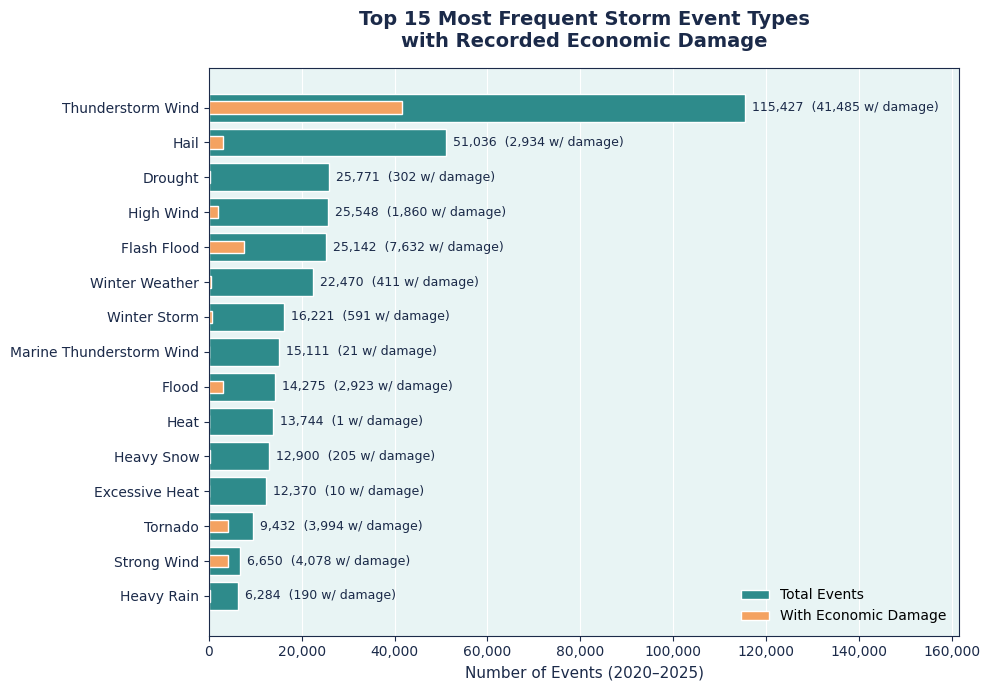

In [6]:
# Count occurrences of each event type and take the top 15
# Sorting descending so the longest bar is at the top for easy reading
event_counts = (
    df['EVENT_TYPE']
    .value_counts()
    .head(15)
)
top15_order = event_counts.index

# --- Economic-damage overlay, added per Andrea's request for Milestone 2 ---
# Mirrors Matt's ANY_ECONOMIC_DAMAGE definition exactly (NOAA_Storm_Impact_Modeling.ipynb):
#   has damage    = TOTAL_ECONOMIC_IMPACT_USD is known and > 0
#   no damage     = TOTAL_ECONOMIC_IMPACT_USD is known and == 0
#   unknown       = TOTAL_ECONOMIC_IMPACT_USD is missing (excluded, not treated as zero)
top15 = df[df['EVENT_TYPE'].isin(top15_order)].copy()
known = top15[top15['TOTAL_ECONOMIC_IMPACT_USD'].notna()]

damage_counts = (
    known[known['TOTAL_ECONOMIC_IMPACT_USD'] > 0]
    .groupby('EVENT_TYPE')
    .size()
    .reindex(top15_order)
    .fillna(0)
    .astype(int)
)

# Sort ascending so the largest bar still lands at the top of a horizontal
# bar chart (barh plots the first row at the bottom)
plot_totals = event_counts.sort_values()
plot_damage = damage_counts.reindex(plot_totals.index)

fig, ax = plt.subplots(figsize=(10, 7))

# Full-height teal bar = total events (unchanged from the original chart)
bars_total = ax.barh(plot_totals.index, plot_totals.values,
                      height=0.8, color=TEAL, edgecolor='white', label='Total Events')

# Thinner orange bar on the same baseline = events with recorded economic damage.
# Same height + y-position as the teal bar is what makes it read as "nested
# inside" the total rather than a separate category next to it.
bars_damage = ax.barh(plot_damage.index, plot_damage.values,
                       height=0.35, color=ACCENT, edgecolor='white', label='With Economic Damage')

# One combined label per row, anchored past the TOTAL bar's end only.
# Two separate labels (one per bar) collide whenever a bar's damage count is
# close to its total (e.g. Strong Wind, Tornado) -- a single label removes
# that collision regardless of how close the two counts are.
for y, (total, damage) in enumerate(zip(plot_totals.values, plot_damage.values)):
    ax.text(
        total + 1500, y,
        f'{total:,.0f}  ({damage:,.0f} w/ damage)',
        va='center', ha='left', fontsize=9, color=NAVY
    )

ax.set_xlabel('Number of Events (2020–2025)', fontsize=11)
ax.set_title('Top 15 Most Frequent Storm Event Types\nwith Recorded Economic Damage', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, plot_totals.max() * 1.4)
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig('chart1_event_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Storm Events by Region

This chart compares total event counts across the four U.S. census regions. The South consistently leads in storm frequency due to its geography and climate exposure.

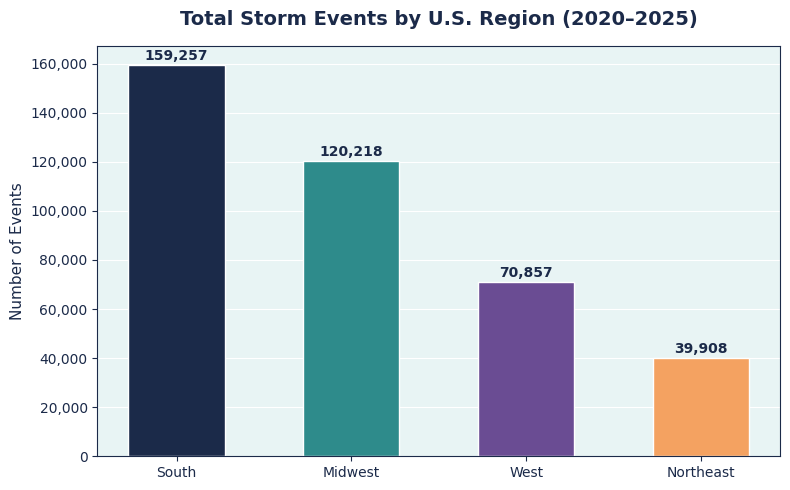

In [7]:
# Filter out rows with no region assignment (territories, marine zones)
# These represent only ~5% of records and are outside the scope of regional comparison
region_counts = (
    df['REGION']
    .dropna()
    .value_counts()
    .reindex(['South', 'Midwest', 'West', 'Northeast'])
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [NAVY, TEAL, PURPLE, ACCENT]
bars = ax.bar(region_counts.index, region_counts.values, color=colors, edgecolor='white', width=0.55)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 1000,
        f'{height:,.0f}', ha='center', va='bottom', fontsize=10, color=NAVY, fontweight='bold'
    )

ax.set_ylabel('Number of Events', fontsize=11)
ax.set_title('Total Storm Events by U.S. Region (2020–2025)', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_events_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Major Property Damage Rate by Season

This chart shows the percentage of events in each season that resulted in major property damage (over $100,000). Rate-based comparison prevents Summer from appearing inflated simply because it has more events.

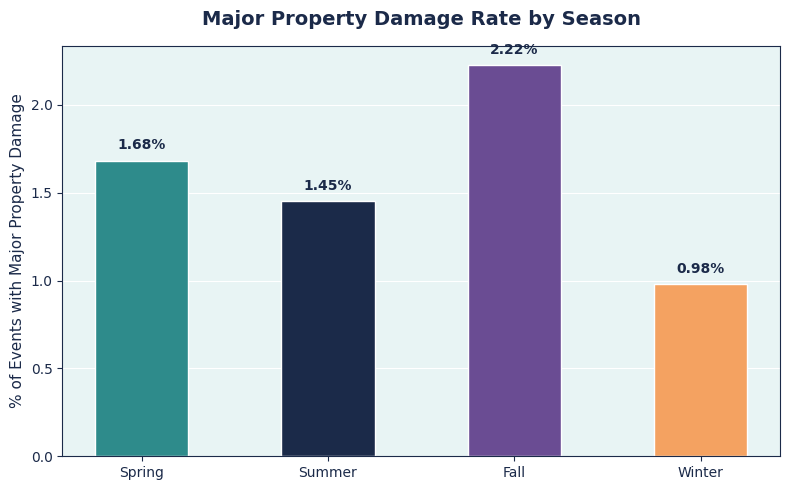

In [8]:
# Calculate the rate of major property damage events per season
# Using rate rather than count because Summer has significantly more events overall
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

season_damage = (
    df.groupby('SEASON')['MAJOR_PROPERTY_DAMAGE']
    .mean()
    .reindex(season_order) * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(season_damage.index, season_damage.values,
              color=[TEAL, NAVY, PURPLE, ACCENT], edgecolor='white', width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.05,
        f'{height:.2f}%', ha='center', va='bottom', fontsize=10, color=NAVY, fontweight='bold'
    )

ax.set_ylabel('% of Events with Major Property Damage', fontsize=11)
ax.set_title('Major Property Damage Rate by Season', pad=15)
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart3_damage_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Top 10 Deadliest Event Types

This chart shows which event types caused the most total fatalities (direct + indirect) across 2020–2025. Rip currents and heat events rank higher than their frequency alone would suggest.

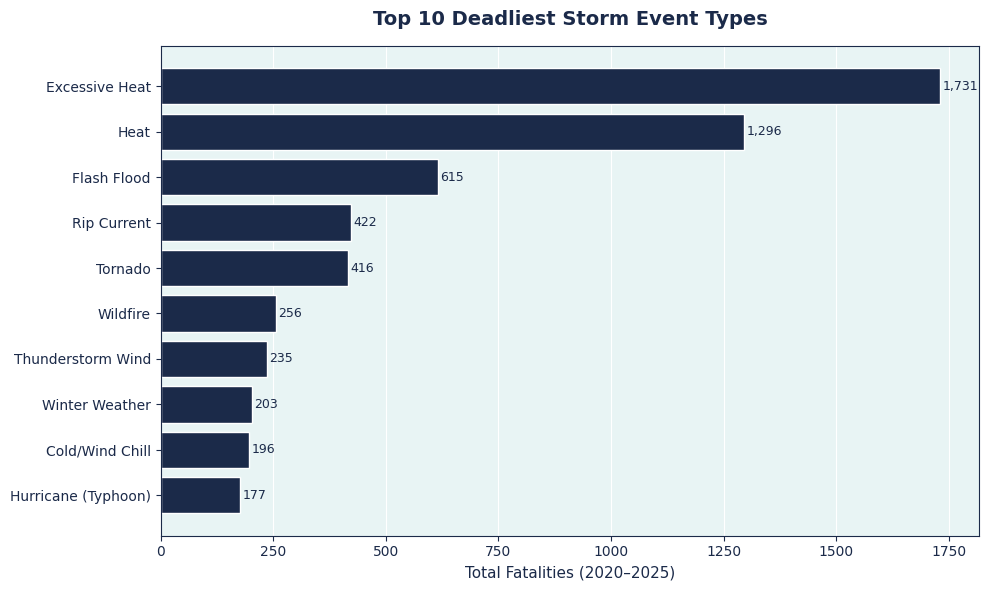

In [9]:
# Sum total fatalities by event type and take the top 10
# TOTAL_FATALITIES = DEATHS_DIRECT + DEATHS_INDIRECT (engineered by Data Wrangler)
fatal_by_type = (
    df.groupby('EVENT_TYPE')['TOTAL_FATALITIES']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(fatal_by_type.index, fatal_by_type.values, color=NAVY, edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5, bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}', va='center', ha='left', fontsize=9, color=NAVY
    )

ax.set_xlabel('Total Fatalities (2020–2025)', fontsize=11)
ax.set_title('Top 10 Deadliest Storm Event Types', pad=15)
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart4_deadliest_events.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Top 10 Event Types by Total Economic Impact

This chart shows total economic damage (property + crop) by event type. Hurricanes and floods dominate despite lower occurrence frequency, illustrating the importance of per-event severity metrics.

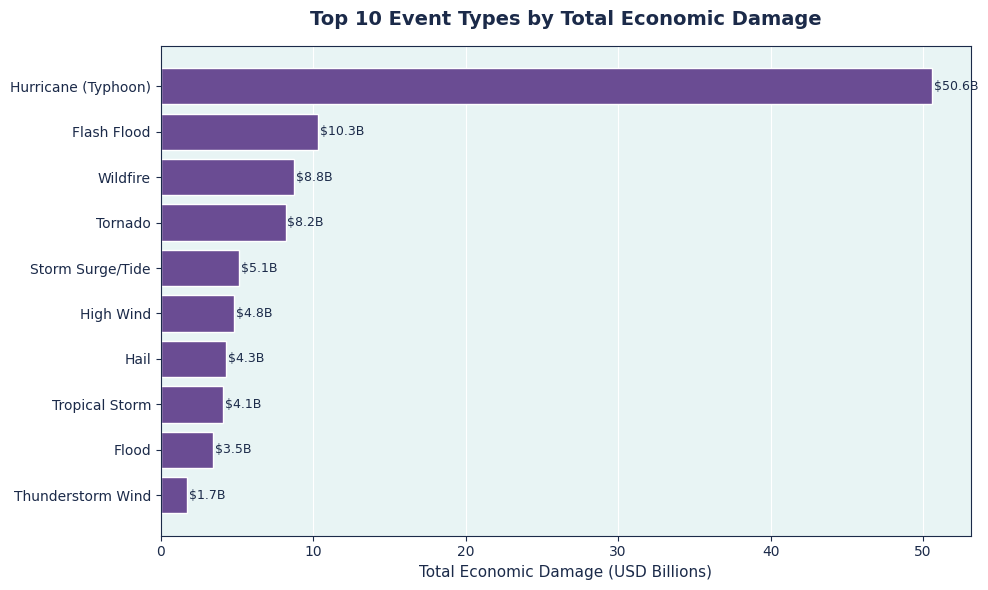

In [ ]:
# Sum total economic impact by event type, convert to billions for readability
# TOTAL_ECONOMIC_IMPACT_USD = PROPERTY_DAMAGE_USD + CROP_DAMAGE_USD
econ_by_type = (
    df.groupby('EVENT_TYPE')['TOTAL_ECONOMIC_IMPACT_USD']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
) / 1_000_000_000  # Convert to billions

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(econ_by_type.index, econ_by_type.values, color=PURPLE, edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1, bar.get_y() + bar.get_height() / 2,
        f'${width:.1f}B', va='center', ha='left', fontsize=9, color=NAVY
    )

ax.set_xlabel('Total Economic Damage (USD Billions)', fontsize=11)
ax.set_title('Top 10 Event Types by Total Economic Damage', pad=15)
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart5_economic_damage.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Year-Over-Year Storm Event Trend (2020–2025)

This line chart tracks total storm event counts per year. An upward trend would support the hypothesis that high-impact events are increasing in frequency over the study period.

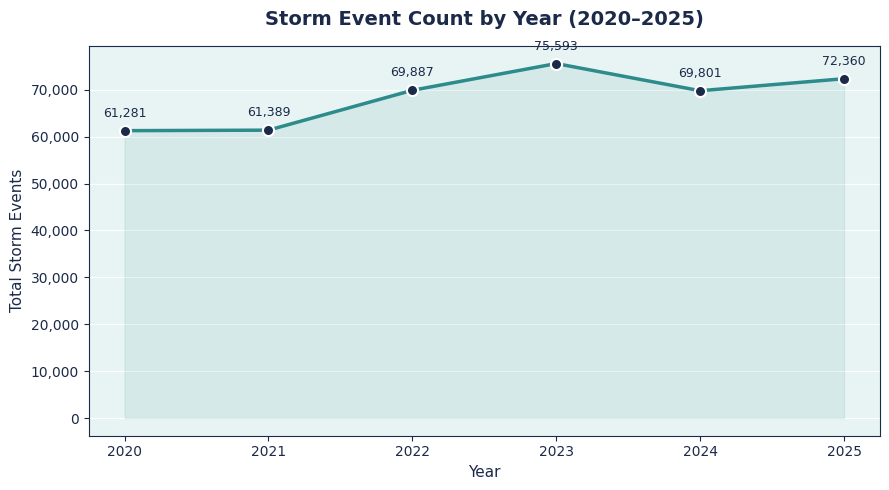

In [10]:
# Count events per year to show temporal trend
# YEAR column is already numeric in the cleaned dataset
yearly = df.groupby('YEAR').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(yearly['YEAR'], yearly['count'], color=TEAL, linewidth=2.5, marker='o',
        markersize=8, markerfacecolor=NAVY, markeredgecolor='white', markeredgewidth=1.5)

# Annotate each point with its count value
for _, row in yearly.iterrows():
    ax.annotate(
        f"{row['count']:,.0f}",
        (row['YEAR'], row['count']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=9, color=NAVY
    )

ax.fill_between(yearly['YEAR'], yearly['count'], alpha=0.1, color=TEAL)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Storm Events', fontsize=11)
ax.set_title('Storm Event Count by Year (2020–2025)', pad=15)
ax.set_xticks(yearly['YEAR'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart6_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 7: Human Impact Heatmap — Region vs Season

This heatmap shows average total human impact (injuries + fatalities) per event, broken out by region and season. Darker cells indicate higher average human impact per event in that combination.

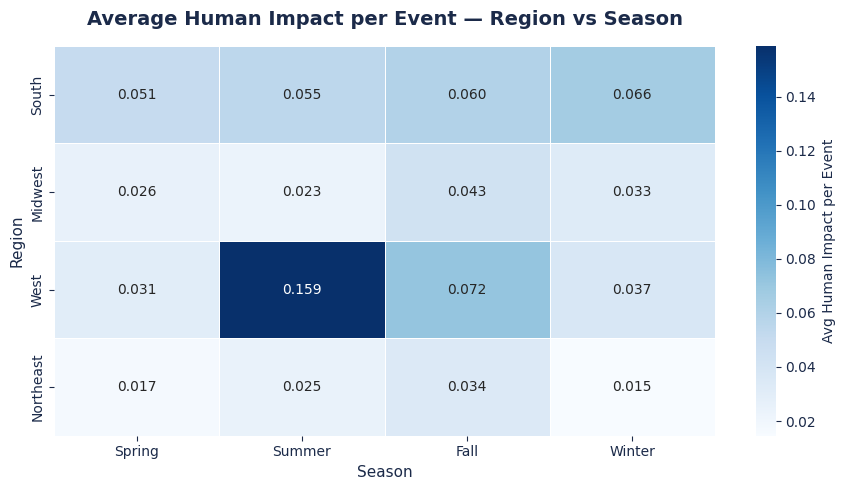

In [11]:
# Build a pivot table of average human impact by region and season
# Using mean per event rather than total to control for event frequency differences
df['TOTAL_HUMAN_IMPACT'] = df['TOTAL_INJURIES'] + df['TOTAL_FATALITIES']

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
region_order = ['South', 'Midwest', 'West', 'Northeast']

heatmap_data = (
    df[df['REGION'].notna()]
    .groupby(['REGION', 'SEASON'])['TOTAL_HUMAN_IMPACT']
    .mean()
    .unstack()
    .reindex(index=region_order, columns=season_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Avg Human Impact per Event'}
)

ax.set_title('Average Human Impact per Event — Region vs Season', pad=15)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Region', fontsize=11)

plt.tight_layout()
plt.savefig('chart7_heatmap_human_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 8: Human Impact Distribution — Events With vs Without

This chart shows the proportion of events that caused any human impact versus those that did not. The class imbalance visible here directly motivates the SMOTE oversampling strategy in the modeling phase.

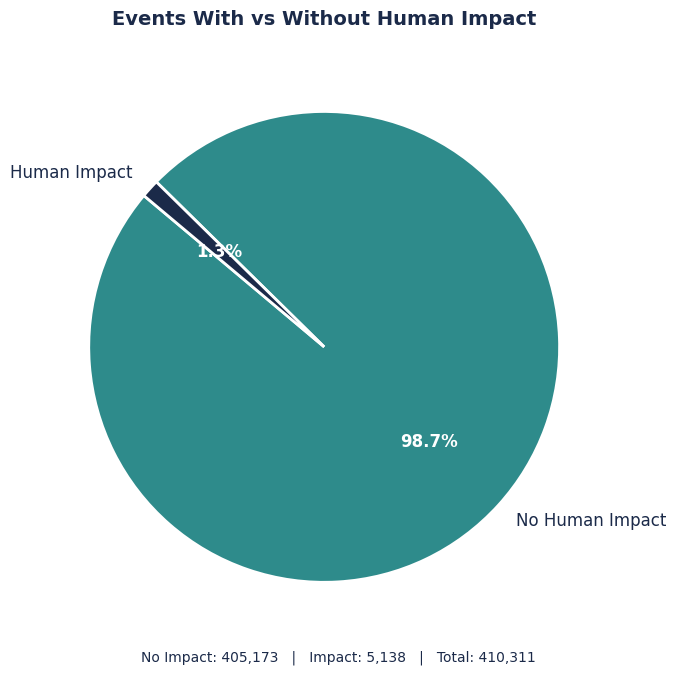

In [12]:
# ANY_HUMAN_IMPACT = 1 if total injuries + fatalities > 0, else 0
# This binary feature is the basis of the HIGH_IMPACT_EVENT target variable
impact_counts = df['ANY_HUMAN_IMPACT'].value_counts().sort_index()
labels = ['No Human Impact', 'Human Impact']
colors_pie = [TEAL, NAVY]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    impact_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'color': NAVY, 'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Events With vs Without Human Impact', pad=20, fontsize=14, fontweight='bold', color=NAVY)

# Add raw count annotation below chart
fig.text(
    0.5, 0.02,
    f'No Impact: {impact_counts[0]:,}   |   Impact: {impact_counts[1]:,}   |   Total: {len(df):,}',
    ha='center', fontsize=10, color=NAVY
)

plt.tight_layout()
plt.savefig('chart8_human_impact_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 9: Random Forest Feature Importance (from Matt's Modeling Notebook)

This chart is built from the permutation importance results in Matt's `NOAA_Storm_Impact_Modeling.ipynb`, which predicts `ANY_ECONOMIC_DAMAGE` using a Random Forest model. Each bar shows how much validation PR-AUC drops when that predictor is randomly shuffled — a larger drop means the model relies on that feature more heavily.

**Note for the team:** Matt's modeling target is `ANY_ECONOMIC_DAMAGE` (any recorded economic damage, yes/no), not the broader `HIGH_IMPACT_EVENT` target defined in the original proposal. It's arguably a cleaner, more defensible target since economic-damage reporting is more complete than injury/fatality reporting, but the proposal/draft should be updated to reflect the change.

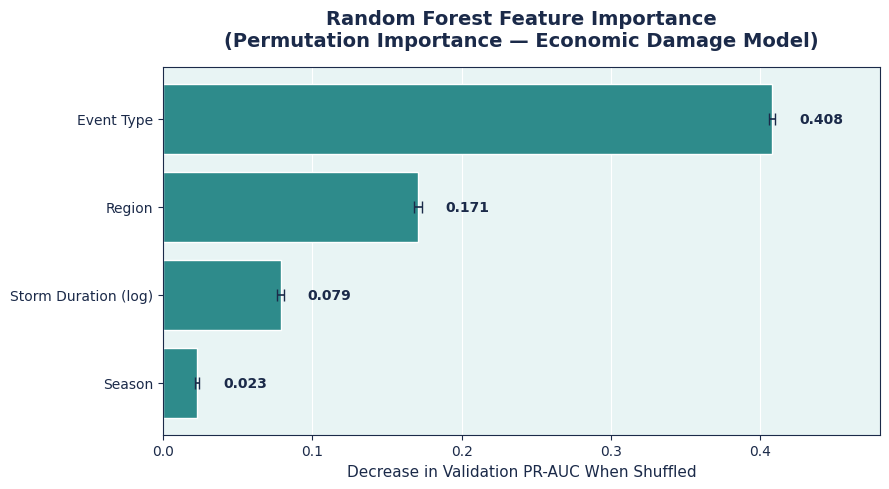

In [13]:
# Feature importance values copied from Matt's permutation_importance() output
# in NOAA_Storm_Impact_Modeling.ipynb (Random Forest, ANY_ECONOMIC_DAMAGE target)
# Values = mean decrease in validation PR-AUC when each predictor is shuffled
labels = ['Season', 'Storm Duration (log)', 'Region', 'Event Type']
values = [0.022830, 0.078831, 0.171075, 0.407707]
errs   = [0.001434, 0.002296, 0.002705, 0.002039]  # std across 10 shuffles

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, xerr=errs, color=TEAL, edgecolor='white',
               error_kw={'ecolor': NAVY, 'capsize': 4, 'elinewidth': 1.2})

for bar, val in zip(bars, values):
    width = bar.get_width()
    ax.text(width + 0.018, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=10, color=NAVY, fontweight='bold')

ax.set_xlabel('Decrease in Validation PR-AUC When Shuffled', fontsize=11)
ax.set_title('Random Forest Feature Importance\n(Permutation Importance \u2014 Economic Damage Model)', pad=15)
ax.set_xlim(0, 0.48)
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** `EVENT_TYPE` dominates (0.408 PR-AUC decrease) — more than double the next-strongest predictor, `REGION` (0.171). `LOG_STORM_DURATION` (0.079) and `SEASON` (0.023) contribute comparatively little. This lines up with Chart 1-5 above: event type alone carries most of the signal for frequency, fatalities, and economic damage, so it's unsurprising it also dominates the predictive model.

## 4. Summary of Findings

These nine visualizations answer the project's research questions. The numbers below are read directly off the rendered charts above; two of the claims in an earlier draft of this summary are corrected here to match what the data actually shows.

- **Thunderstorm Wind** is by far the most frequent event type (115,427 events) — more than double Hail (51,036), the second-most frequent. Frequency does not equal severity: Thunderstorm Wind causes only 235 total fatalities, far below several much-less-frequent event types.
- **The South** leads all regions with 159,257 events, ahead of the Midwest (120,218), West (70,857), and Northeast (39,908) — consistent with its size, tropical exposure, and convective climate.
- **Fall, not Winter, has the highest major-property-damage rate** at 2.22% of events, followed by Spring (1.68%) and Summer (1.45%); Winter is actually the *lowest* at 0.98%. This tracks with Fall being peak hurricane season across the South.
- **Excessive Heat (1,731 deaths) and Heat (1,296 deaths)** are the two deadliest event types by total fatalities — together they account for more deaths than the next six categories combined. Flash Flood (615), Rip Current (422), and Tornado (416) follow well behind.
- **Hurricane (Typhoon)** dominates economic damage at \$50.6B, roughly five times the second-place category, Flash Flood (\$10.3B). Tropical Storm damage is comparatively modest (\$4.1B, 8th of 10) — so the earlier framing of "hurricanes and tropical storms" jointly driving damage overstated tropical storms' role; hurricanes alone carry the bulk of the loss.
- Yearly event counts rose from 61,281 (2020) to a peak of 75,593 (2023), dipped to 69,801 (2024), then ticked back up to 72,360 (2025). This reads more as a plateau in the high-60/low-70 thousands after an initial jump than a clean upward trend.
- **West + Summer** is the standout cell in the human-impact heatmap at 0.159 average impact per event — roughly 2-7x higher than any other region/season combination, including South + Summer (0.055). This is likely driven by wildfire and extreme-heat events concentrated in western summers, not by the South as the earlier draft assumed.
- The overwhelming majority of events — 405,173 of 410,311 (98.7%) — cause **no human impact**, versus 5,138 (1.3%) that do, confirming the severe class imbalance the modeling phase will need to address (e.g., with SMOTE).
- **Chart 9 (added from Matt's modeling notebook):** Random Forest permutation importance confirms `EVENT_TYPE` as the dominant predictor of economic damage (0.408 PR-AUC decrease when shuffled), more than double `REGION` (0.171); `LOG_STORM_DURATION` (0.079) and `SEASON` (0.023) matter far less. This is consistent with event type driving the frequency, fatality, and damage patterns seen in Charts 1 and 5. Note: Matt's model predicts `ANY_ECONOMIC_DAMAGE`, not the `HIGH_IMPACT_EVENT` target from the original proposal — worth flagging in the Milestone draft.
- **Chart 1 update (economic-damage overlay, added for Milestone 2):** Thunderstorm Wind has both the most events (115,427) and the most with recorded damage (41,485, a 49.6% rate among known outcomes). But rate tells a different story than volume: **Strong Wind (93.1%) and Tornado (54.8%)** have far higher damage rates despite being near the bottom of the frequency list, while **Heat and Excessive Heat sit near 0%** — consistent with Chart 4's finding that heat events drive fatalities, not property damage. Economic outcome is unknown for roughly 20–35% of events in most categories (0% for Flash Flood and Flood), so every damage count here is a floor, not a ceiling.

## 5. Reflection on Visualization Choices

Checked against this course's two assigned texts — Wilke's *Fundamentals of Data Visualization* and Healy's *Data Visualization: A Practical Introduction* — these charts follow their recommendations closely, with one clear exception.

- **Horizontal bars for long labels** (Charts 1, 4, 5) match Wilke directly. He recommends swapping the x/y axes over rotating tick labels whenever category names are long, calling rotated labels "awkward and difficult to read" and horizontal bars the "better solution" (Ch. 6, *Bar Plots*).
- **Bar ordering** follows his rule as well: Charts 1, 4, and 5 are sorted by value because event types have no natural order ("we should only rearrange bars ... when there is no natural ordering to the categories"), while Charts 2 (region), 3 (season), and 6 (year) keep their categorical/calendar/temporal order instead of sorting by size — exactly the exception Wilke carves out for variables that *do* have a natural ordering.
- **The heatmap** (Chart 7) is textbook-correct on two counts. Wilke lists mapping two categorical axes plus a magnitude onto color as the standard way to extend a bar-style "amounts" chart into two dimensions, and the single-hue Blues colormap used here is precisely the sequential-palette type he recommends for continuous values ("a monochromatic scale that varies from dark to light blue," Ch. 4).
- **Zero-baselined bars and single-hue series** (Charts 1, 4, 5) satisfy Wilke's principle of proportional ink — shaded area proportional to value, no truncated axes. Charts 2 and 3 do color each bar differently even though color isn't encoding any variable beyond what the x-axis labels already show; that's a minor decorative flourish rather than a violation, since it's not misrepresenting anything.
- **The pie chart** (Chart 8) is the one real deviation, and both assigned texts single out exactly this case. Wilke: pie charts "work well when the goal is to emphasize simple fractions, such as one-half, one-third, or one-quarter" — 98.7%/1.3% isn't one of those. Healy is more direct: "the perceptual qualities of pie charts are not great... A Cleveland dot plot or a bar chart is usually a much more straightforward way of comparing quantities" (*Saying No to Pie*, p. 224–225). A bar or a simple stat callout would follow both texts' guidance more closely than the pie chart does here.

**Bottom line:** 7 of the 8 charts follow the recommendations in both assigned readings. The pie chart is the one place this notebook diverges from what Wilke and Healy explicitly recommend against.